# E-Commerce Customer Sales & Retention Analysis

## Business Problem

The company wants to understand what drives sales, which customer segments generate the most revenue, how discounts relate to purchasing behavior and profitability, and which customers are becoming inactive.

### Business questions
1. Which product categories generate the most sales?
2. Which categories generate the most profit?
3. Which customer segments generate the most revenue?
4. Which customers are high-value customers?
5. How does discount level relate to profit margin?
6. Which months have the highest sales?
7. Which customer groups have the highest inactivity?
8. What payment methods are most commonly used?
9. What factors are associated with higher order value?
10. What practical actions could the business consider?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the CSV file
df_raw = pd.read_csv("ecommerce_sales.csv")

# Display more columns
pd.set_option("display.max_columns", 50)

# Set Seaborn style
sns.set_theme(style="whitegrid")

print("Data loaded successfully!")
print("Dataset shape:", df_raw.shape)

Data loaded successfully!
Dataset shape: (8003, 20)


### What did I do?
Loaded the CSV into a Pandas DataFrame.

### Why did I do it?
EDA starts by understanding the structure and quality of the data before calculating business metrics.

### What did I learn?
The next cells inspect the records, columns, data types, and distributions.

In [5]:
display(df_raw.head())
display(df_raw.tail())
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())
print("\nData types:")
df_raw.info()
display(df_raw.describe(include="all").T)

,customer_id,customer_age,gender,city,customer_segment,signup_date,order_id,order_date,product_id,product_category,quantity,unit_price,discount_percent,payment_method,order_status,gross_sales,discount_amount,net_sales,profit,profit_margin
0,11755,43,Female,Pune,Premium,2025-04-11,O102926,2025-01-01 01:00:00,P1100,Fashion,1.0,4609.93,10.0,Cash on Delivery,Delivered,4609.93,460.99,4148.94,1983.01,47.80
1,11647,32,Male,Pune,Regular,2025-07-22,O100081,2025-01-01 01:26:00,P1169,Home & Kitchen,2.0,1315.77,10.0,Net Banking,Delivered,2631.54,263.15,2368.39,756.05,31.92
2,11975,21,Male,Pune,Regular,2025-06-01,O105344,2025-01-01 01:46:00,P1120,Beauty,2.0,2838.39,10.0,Debit Card,Delivered,5676.78,567.68,5109.10,2523.48,49.39
3,10737,40,Male,Pune,Regular,2025-01-06,O101626,2025-01-01 02:22:00,P1041,Home & Kitchen,2.0,1940.13,5.0,Credit Card,Delivered,3880.26,194.01,3686.25,1181.17,32.04
4,11814,33,Female,Hyderabad,Premium,2025-10-01,O102755,2025-01-01 02:40:00,P1316,Books,2.0,914.49,5.0,Credit Card,Delivered,1828.98,91.45,1737.53,702.52,40.43


,customer_id,customer_age,gender,city,customer_segment,signup_date,order_id,order_date,product_id,product_category,quantity,unit_price,discount_percent,payment_method,order_status,gross_sales,discount_amount,net_sales,profit,profit_margin
7998,11630,43,Male,Ahmedabad,Regular,2025-01-28,O100326,2025-12-31 23:04:00,P1116,Beauty,3.0,3864.08,0.0,UPI,Delivered,11592.24,0.00,11592.24,5569.08,48.04
7999,10607,40,Female,Bengaluru,Regular,2025-03-12,O102720,2025-12-31 23:10:00,P1034,Electronics,2.0,34279.62,5.0,UPI,Delivered,68559.24,3427.96,65131.28,14238.64,21.86
8000,10309,38,Male,Pune,Regular,2025-08-30,O102101,2025-01-05 21:04:00,P1020,Electronics,1.0,17983.23,5.0,Credit Card,Delivered,17983.23,899.16,17084.07,3694.98,21.63
8001,12131,34,Female,Ahmedabad,Regular,2025-06-17,O103865,2025-01-12 03:10:00,P1050,Books,3.0,812.29,0.0,Debit Card,Delivered,2436.87,0.00,2436.87,896.61,36.79
8002,10731,37,Female,Hyderabad,Regular,2025-10-18,O103745,2025-01-23 08:04:00,P1274,Fashion,2.0,2865.73,15.0,UPI,Delivered,5731.46,859.72,4871.74,2116.22,43.44


Shape: (8003, 20)

Columns:
['customer_id', 'customer_age', 'gender', 'city', 'customer_segment', 'signup_date', 'order_id', 'order_date', 'product_id', 'product_category', 'quantity', 'unit_price', 'discount_percent', 'payment_method', 'order_status', 'gross_sales', 'discount_amount', 'net_sales', 'profit', 'profit_margin']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8003 entries, 0 to 8002
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       8003 non-null   int64  
 1   customer_age      8003 non-null   int64  
 2   gender            8003 non-null   object 
 3   city              8003 non-null   object 
 4   customer_segment  8003 non-null   object 
 5   signup_date       8003 non-null   object 
 6   order_id          8003 non-null   object 
 7   order_date        8002 non-null   object 
 8   product_id        8003 non-null   object 
 9   product_category  8003 non-null

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,8003.0,NaN,NaN,NaN,11103.357866,633.337163,10001.0,10550.0,11108.0,11646.0,12200.0
customer_age,8003.0,NaN,NaN,NaN,33.084093,8.454507,18.0,27.0,33.0,39.0,62.0
gender,8003,3,Male,3976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,8003,8,Mumbai,1596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,8003,3,Regular,4196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,8003,364,2025-12-26,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,8003,8000,O103865,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,8002,7932,2025-03-22 23:11:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,8003,350,P1029,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,8003,6,Fashion,1795,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning
We check missing values, duplicates, invalid numeric values, invalid dates, and unexpected categories. Only a small number of intentionally inserted quality issues are present.


In [9]:
print("Missing values before cleaning:")
display(df_raw.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("Duplicate rows before cleaning:", df_raw.duplicated().sum())

checks = {
    "invalid_quantity": (df_raw["quantity"].le(0) | df_raw["quantity"].isna()).sum(),
    "invalid_unit_price": (df_raw["unit_price"].le(0) | df_raw["unit_price"].isna()).sum(),
    "invalid_discount": (~df_raw["discount_percent"].between(0, 100) | df_raw["discount_percent"].isna()).sum(),
    "invalid_order_date": pd.to_datetime(df_raw["order_date"], errors="coerce").isna().sum(),
    "unexpected_payment_method": (~df_raw["payment_method"].isin(
        ["UPI", "Credit Card", "Debit Card", "Net Banking", "Cash on Delivery"]
    )).sum()
}
display(pd.Series(checks, name="count").to_frame())

Missing values before cleaning:


,missing_count
quantity,1
order_date,1
customer_id,0
customer_age,0
city,0
gender,0
signup_date,0
customer_segment,0
order_id,0
product_id,0


Duplicate rows before cleaning: 3


,count
invalid_quantity,1
invalid_unit_price,1
invalid_discount,1
invalid_order_date,1
unexpected_payment_method,1


In [11]:
from data_cleaning import clean_orders

df = clean_orders(df_raw)

print("Rows before cleaning:", len(df_raw))
print("Rows after cleaning:", len(df))
print("Rows removed:", len(df_raw) - len(df))
print("Duplicates after cleaning:", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_after_cleaning"))

Rows before cleaning: 8003
Rows after cleaning: 7996
Rows removed: 7
Duplicates after cleaning: 0


,missing_after_cleaning
payment_method,1
customer_age,0
gender,0
city,0
customer_id,0
customer_segment,0
signup_date,0
order_date,0
order_id,0
product_category,0


### What did I do?
Converted dates and numeric columns, removed duplicate records, handled invalid values, removed records with essential missing order fields, and recalculated sales/profit measures.

### Why did I do it?
Business conclusions depend on valid quantities, prices, discounts, and dates.

### What did I learn?
Cleaning is targeted rather than excessive; only records with issues that could affect the analysis are removed.

## Feature Engineering
Business metrics are created from source fields so their definitions are transparent.

In [12]:
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * df["discount_percent"] / 100
df["net_sales"] = df["gross_sales"] - df["discount_amount"]
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["quarter"] = "Q" + df["order_date"].dt.quarter.astype(str)
df["year"] = df["order_date"].dt.year
df["day_of_week"] = df["order_date"].dt.day_name()

df["customer_age_group"] = pd.cut(
    df["customer_age"],
    bins=[17, 24, 34, 44, 54, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)

df["discount_group"] = pd.cut(
    df["discount_percent"],
    bins=[-0.01, 0, 10, 20, 100],
    labels=["No Discount", "Low Discount", "Medium Discount", "High Discount"]
)

display(df[[
    "quantity", "unit_price", "gross_sales", "discount_percent",
    "discount_amount", "net_sales", "profit", "profit_margin",
    "month", "quarter", "customer_age_group"
]].head())

,quantity,unit_price,gross_sales,discount_percent,discount_amount,net_sales,profit,profit_margin,month,quarter,customer_age_group
0,1.0,4609.93,4609.93,10.0,460.993,4148.937,1867.02165,45.0,2025-01,Q1,35-44
1,2.0,1315.77,2631.54,10.0,263.154,2368.386,805.25124,34.0,2025-01,Q1,25-34
2,2.0,2838.39,5676.78,10.0,567.678,5109.102,2554.55100,50.0,2025-01,Q1,18-24
3,2.0,1940.13,3880.26,5.0,194.013,3686.247,1253.32398,34.0,2025-01,Q1,35-44
4,2.0,914.49,1828.98,5.0,91.449,1737.531,660.26178,38.0,2025-01,Q1,25-34


In [13]:
customer_summary = (
    df.groupby("customer_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_sales=("net_sales", "sum"),
          total_profit=("profit", "sum"),
          average_order_value=("net_sales", "mean"),
          last_order_date=("order_date", "max"),
          customer_segment=("customer_segment", "first")
      )
      .reset_index()
)

customer_summary["days_since_last_order"] = (
    df["order_date"].max() - customer_summary["last_order_date"]
).dt.days

customer_summary["activity_status"] = pd.cut(
    customer_summary["days_since_last_order"],
    bins=[-1, 30, 90, np.inf],
    labels=["Active", "Recently Inactive", "Inactive"]
)

# Revenue-based customer value rules using simple tertiles.
q1, q2 = customer_summary["total_sales"].quantile([1/3, 2/3])
customer_summary["value_segment"] = pd.cut(
    customer_summary["total_sales"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low Value", "Medium Value", "High Value"]
)

display(customer_summary.head())

,customer_id,total_orders,total_sales,total_profit,average_order_value,last_order_date,customer_segment,days_since_last_order,activity_status,value_segment
0,10001,5,20767.7685,9011.937540,4153.553700,2025-09-08 07:20:00,Regular,114,Inactive,Low Value
1,10002,5,106893.4305,32609.107965,21378.686100,2025-12-05 22:20:00,Premium,26,Active,High Value
2,10003,7,301677.5945,75931.863875,43096.799214,2025-12-30 07:06:00,Regular,1,Active,High Value
3,10004,1,18714.1525,9357.076250,18714.152500,2025-05-10 15:17:00,Regular,235,Inactive,Low Value
4,10005,3,31400.3920,14065.923030,10466.797333,2025-12-13 06:13:00,Regular,18,Active,Low Value


### What did I do?
Created time fields, age groups, discount groups, and a customer-level summary.

### Why did I do it?
These features make it easier to answer business questions at both order level and customer level.

### What did I learn?
The customer summary lets us compare customer value and inactivity without using complex machine learning.

## Univariate Analysis

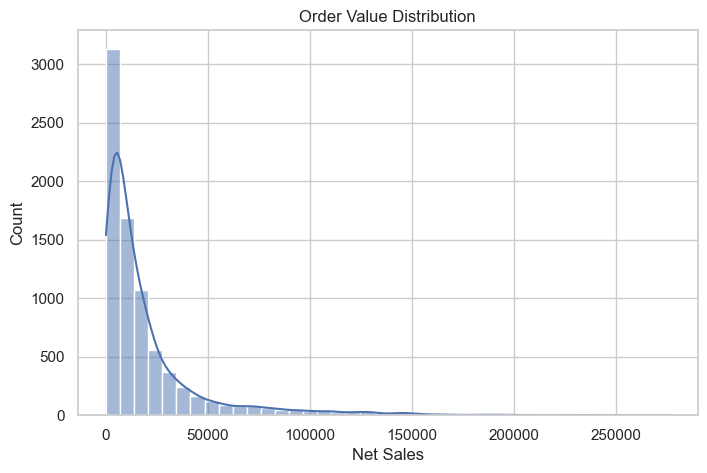

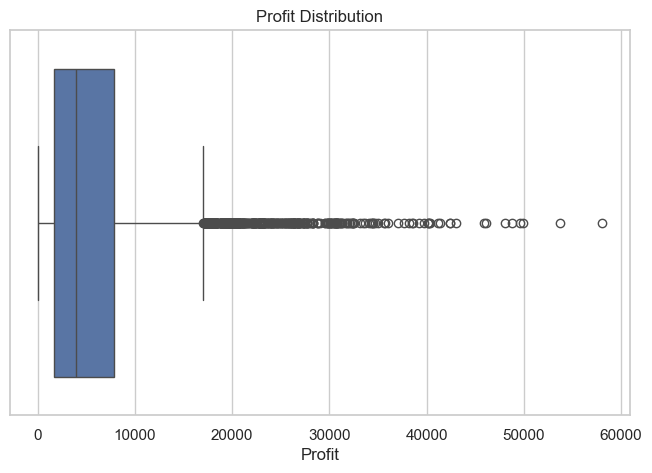

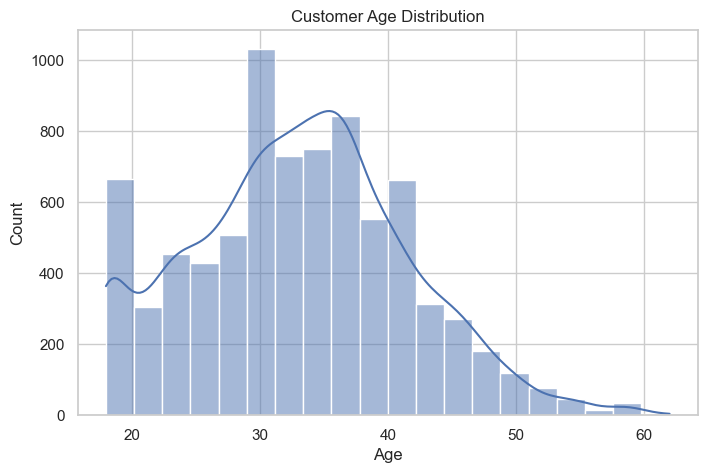

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["net_sales"], bins=40, kde=True, ax=ax)
ax.set_title("Order Value Distribution")
ax.set_xlabel("Net Sales")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df["profit"], ax=ax)
ax.set_title("Profit Distribution")
ax.set_xlabel("Profit")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["customer_age"], bins=20, kde=True, ax=ax)
ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
plt.show()

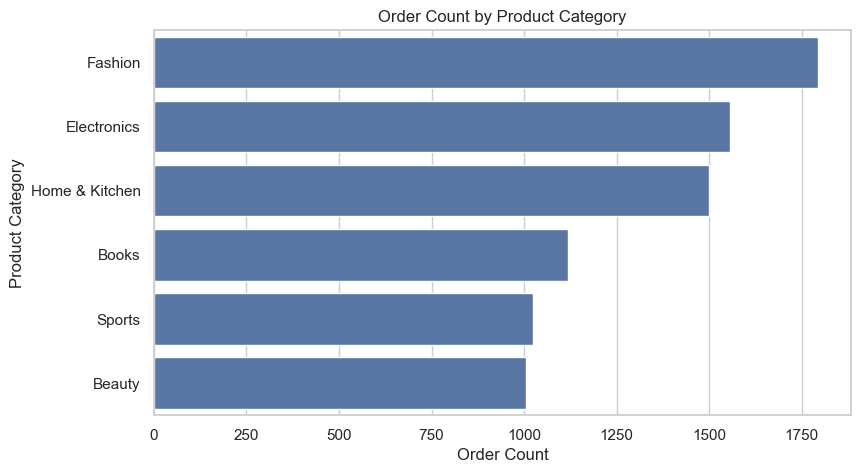

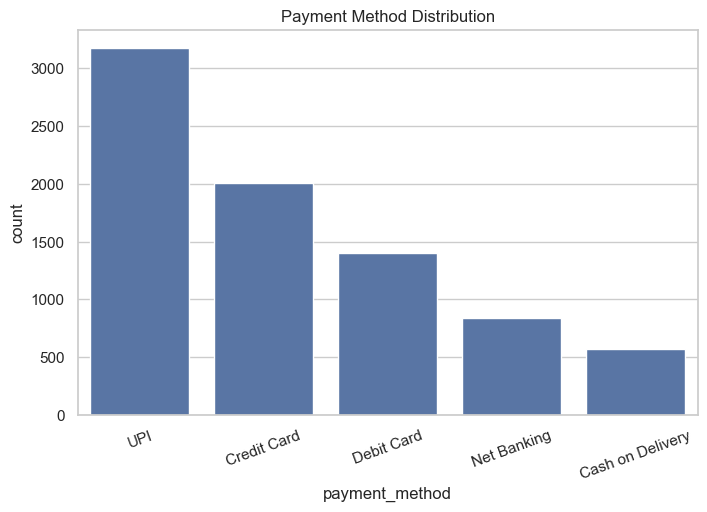

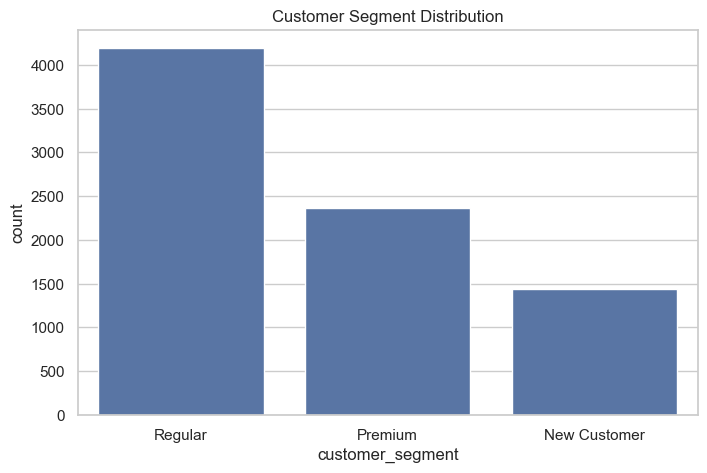

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, y="product_category", order=df["product_category"].value_counts().index, ax=ax)
ax.set_title("Order Count by Product Category")
ax.set_xlabel("Order Count")
ax.set_ylabel("Product Category")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="payment_method", order=df["payment_method"].value_counts().index, ax=ax)
ax.set_title("Payment Method Distribution")
ax.tick_params(axis="x", rotation=20)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="customer_segment", order=df["customer_segment"].value_counts().index, ax=ax)
ax.set_title("Customer Segment Distribution")
plt.show()

## Bivariate Analysis

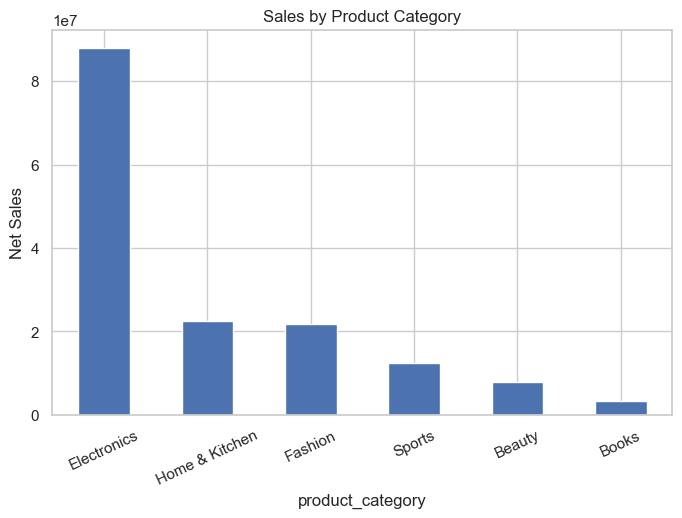

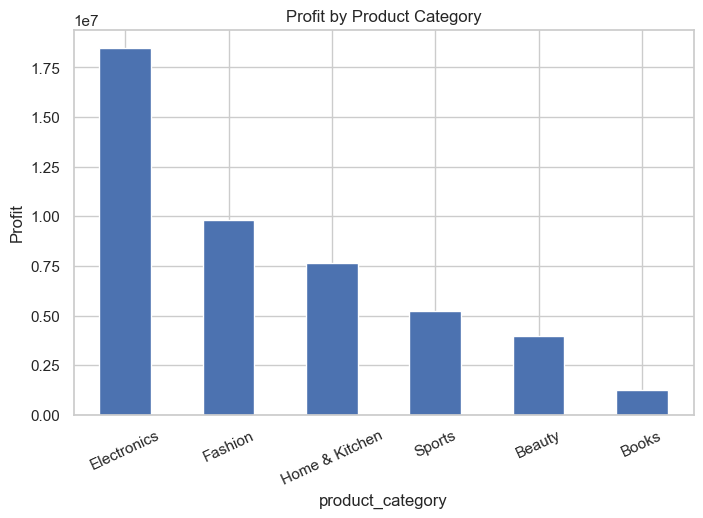

In [16]:
category_sales = df.groupby("product_category")["net_sales"].sum().sort_values(ascending=False)
category_profit = df.groupby("product_category")["profit"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
category_sales.plot(kind="bar", ax=ax)
ax.set_title("Sales by Product Category")
ax.set_ylabel("Net Sales")
ax.tick_params(axis="x", rotation=25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
category_profit.plot(kind="bar", ax=ax)
ax.set_title("Profit by Product Category")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=25)
plt.show()

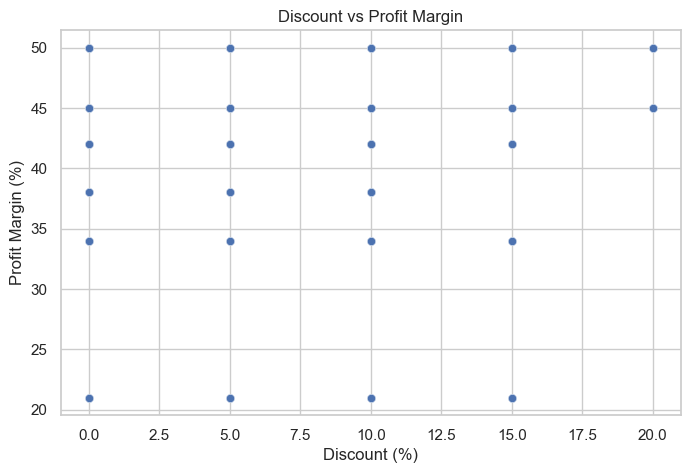

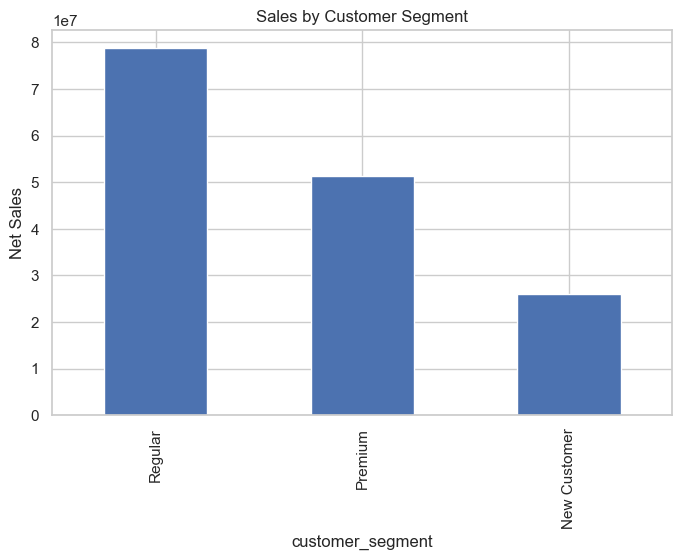

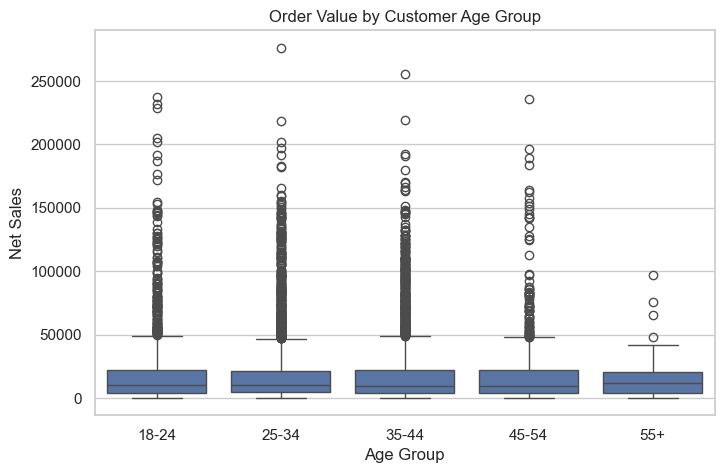

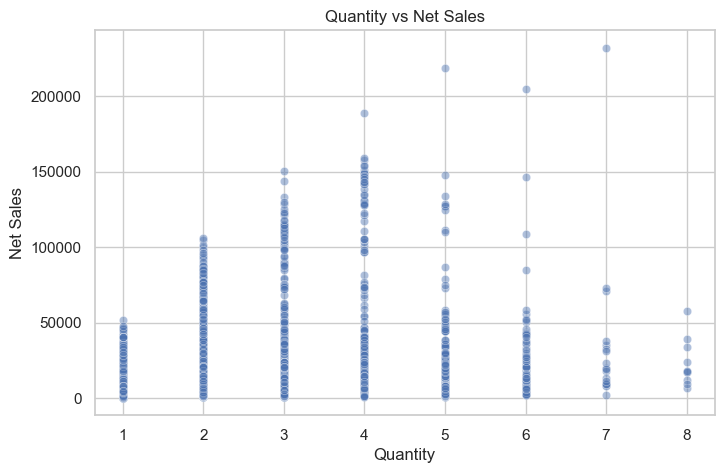

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42),
                x="discount_percent", y="profit_margin", alpha=0.45, ax=ax)
ax.set_title("Discount vs Profit Margin")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit Margin (%)")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
segment_sales = df.groupby("customer_segment")["net_sales"].sum().sort_values(ascending=False)
segment_sales.plot(kind="bar", ax=ax)
ax.set_title("Sales by Customer Segment")
ax.set_ylabel("Net Sales")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="customer_age_group", y="net_sales", ax=ax)
ax.set_title("Order Value by Customer Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Net Sales")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42),
                x="quantity", y="net_sales", alpha=0.45, ax=ax)
ax.set_title("Quantity vs Net Sales")
ax.set_xlabel("Quantity")
ax.set_ylabel("Net Sales")
plt.show()

### What did I do?
Compared sales, profit, discounts, customer segments, age groups, and quantity.

### Why did I do it?
Bivariate analysis helps identify relationships that can support business decisions.

### What did I learn?
The exact findings are calculated below from the cleaned dataset rather than assumed in advance.

## Time-Series EDA

In [ ]:
monthly = (
    df.set_index("order_date")
      .resample("MS")
      .agg(
          monthly_sales=("net_sales", "sum"),
          monthly_profit=("profit", "sum"),
          order_count=("order_id", "nunique"),
          average_order_value=("net_sales", "mean")
      )
      .reset_index()
)

display(monthly)

for metric, title, ylabel in [
    ("monthly_sales", "Monthly Sales Trend", "Net Sales"),
    ("monthly_profit", "Monthly Profit Trend", "Profit"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(monthly["order_date"], monthly[metric], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

print("Highest sales month:", monthly.loc[monthly["monthly_sales"].idxmax(), "order_date"].strftime("%Y-%m"))
print("Highest profit month:", monthly.loc[monthly["monthly_profit"].idxmax(), "order_date"].strftime("%Y-%m"))

### Interpretation guide
This is descriptive time-series analysis only. We look for peaks, dips, and visible patterns; we do not build a forecasting model.

## Customer Analysis

In [19]:
print("Total customers:", customer_summary["customer_id"].nunique())
print("Total orders:", df["order_id"].nunique())
print("Average orders per customer:", round(df["order_id"].nunique() / customer_summary["customer_id"].nunique(), 2))
print("Average customer revenue:", round(customer_summary["total_sales"].mean(), 2))

top_revenue = customer_summary.nlargest(10, "total_sales")
top_profit = customer_summary.nlargest(10, "total_profit")

display(top_revenue[["customer_id", "total_orders", "total_sales", "average_order_value", "value_segment"]])
display(top_profit[["customer_id", "total_orders", "total_profit", "value_segment"]])

Total customers: 2090
Total orders: 7996
Average orders per customer: 3.83
Average customer revenue: 74613.8


,customer_id,total_orders,total_sales,average_order_value,value_segment
649,10690,12,492398.2380,41033.186500,High Value
2025,12133,8,440236.7040,55029.588000,High Value
1373,11450,9,437865.1005,48651.677833,High Value
1530,11613,6,383367.2455,63894.540917,High Value
1189,11255,11,374928.6865,34084.426045,High Value
636,10677,6,374260.2630,62376.710500,High Value
1558,11642,7,362138.6145,51734.087786,High Value
1463,11544,7,356277.1060,50896.729429,High Value
676,10719,9,354709.9045,39412.211611,High Value
1459,11540,7,352597.2600,50371.037143,High Value


,customer_id,total_orders,total_profit,value_segment
649,10690,12,127577.350620,High Value
2025,12133,8,111007.010625,High Value
1189,11255,11,106271.542640,High Value
1373,11450,9,105041.746665,High Value
554,10590,15,100844.747280,High Value
1463,11544,7,96818.846655,High Value
1608,11695,10,94844.069005,High Value
1530,11613,6,92277.039275,High Value
1558,11642,7,92214.446780,High Value
676,10719,9,91194.506870,High Value


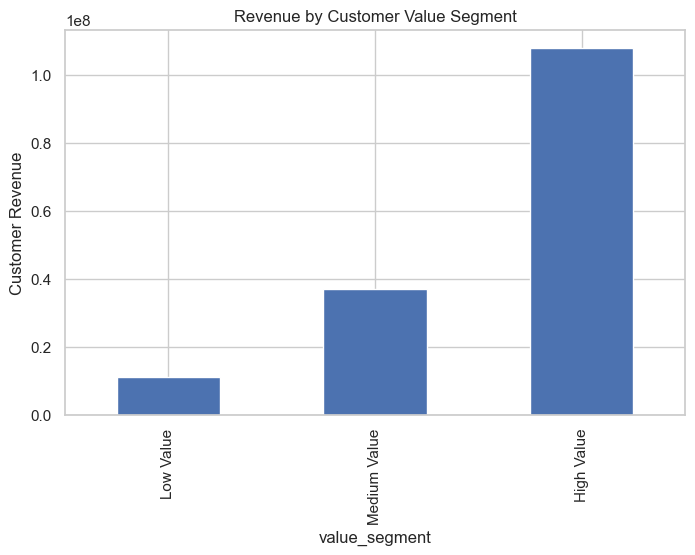

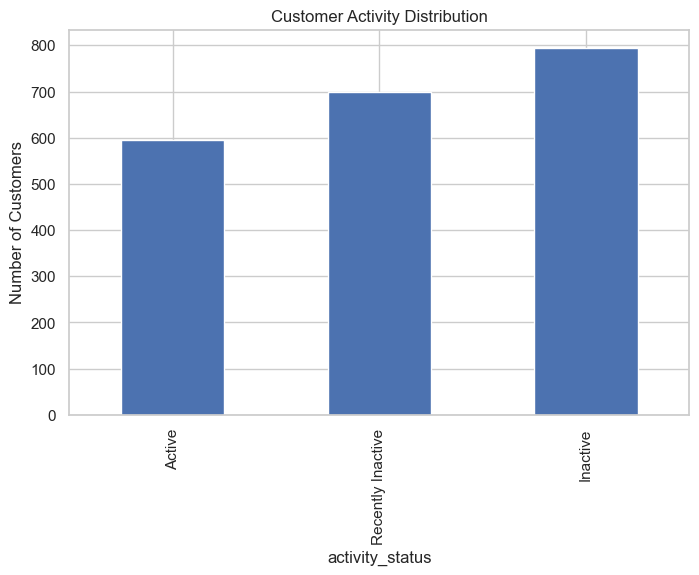

In [20]:
value_sales = customer_summary.groupby("value_segment", observed=True)["total_sales"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
value_sales.plot(kind="bar", ax=ax)
ax.set_title("Revenue by Customer Value Segment")
ax.set_ylabel("Customer Revenue")
plt.show()

activity_counts = customer_summary["activity_status"].value_counts().reindex(
    ["Active", "Recently Inactive", "Inactive"]
)

fig, ax = plt.subplots(figsize=(8, 5))
activity_counts.plot(kind="bar", ax=ax)
ax.set_title("Customer Activity Distribution")
ax.set_ylabel("Number of Customers")
plt.show()

## Customer Retention / Inactivity

The activity thresholds are simple business rules:
- **Active:** 0–30 days
- **Recently Inactive:** 31–90 days
- **Inactive:** 90+ days

These are analytical classifications, not machine-learning predictions.

In [21]:
activity_revenue = (
    customer_summary.groupby("activity_status", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_sales", "sum")
    )
    .reset_index()
)

segment_activity = pd.crosstab(
    customer_summary["customer_segment"],
    customer_summary["activity_status"]
)

display(activity_revenue)
display(segment_activity)

,activity_status,customers,revenue
0,Active,596,5.828582e+07
1,Recently Inactive,700,5.971009e+07
2,Inactive,794,3.794694e+07


activity_status,Active,Recently Inactive,Inactive
customer_segment,,,
New Customer,106,165,283
Premium,150,161,84
Regular,340,374,427


## Discount Analysis

,discount_group,orders,average_sales,average_profit,average_profit_margin
0,No Discount,1519,18821.094931,5550.494806,36.797893
1,Low Discount,4879,20790.331548,5997.884927,36.735397
2,Medium Discount,1598,16218.761113,5432.373771,40.664581


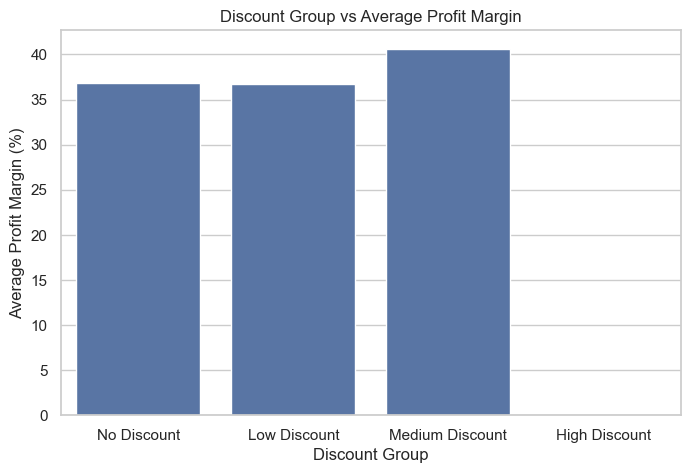

In [23]:
discount_summary = (
    df.groupby("discount_group", observed=True)
      .agg(
          orders=("order_id", "nunique"),
          average_sales=("net_sales", "mean"),
          average_profit=("profit", "mean"),
          average_profit_margin=("profit_margin", "mean")
      )
      .reset_index()
)

display(discount_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=discount_summary, x="discount_group", y="average_profit_margin", ax=ax)
ax.set_title("Discount Group vs Average Profit Margin")
ax.set_xlabel("Discount Group")
ax.set_ylabel("Average Profit Margin (%)")
plt.show()

### Important interpretation
If higher discount groups have lower average profit margins, the safe statement is that **higher discount levels are associated with lower average profit margins in this dataset**. This does not prove that discounts caused the lower margins because other factors, such as product mix, can also influence profitability.

## Statistical Analysis

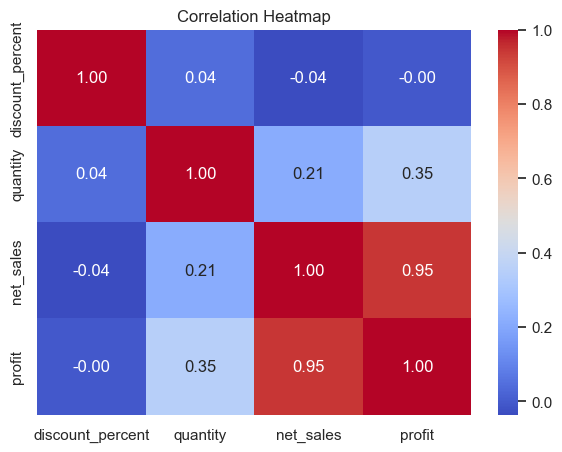

H0: Mean order value is the same for New Customer and Regular groups.
H1: Mean order value is different between the two groups.
t-statistic: -1.0
p-value: 0.31734
Significance level: 0.05
Decision: Fail to reject H0 at the 5% significance level.


In [24]:
corr_cols = ["discount_percent", "quantity", "net_sales", "profit"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

# Optional, simple independent two-sample t-test:
# Compare AOV of New Customers vs Regular Customers.
new_aov = df.loc[df["customer_segment"] == "New Customer"].groupby("order_id")["net_sales"].sum()
regular_aov = df.loc[df["customer_segment"] == "Regular"].groupby("order_id")["net_sales"].sum()

t_stat, p_value = stats.ttest_ind(new_aov, regular_aov, equal_var=False)

print("H0: Mean order value is the same for New Customer and Regular groups.")
print("H1: Mean order value is different between the two groups.")
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))
print("Significance level: 0.05")

if p_value < 0.05:
    print("Decision: Reject H0 at the 5% significance level.")
else:
    print("Decision: Fail to reject H0 at the 5% significance level.")

### What does the test mean?
- **Null hypothesis (H0):** the two groups have the same mean order value.
- **Alternative hypothesis (H1):** their mean order values are different.
- **p-value:** measures how compatible the observed difference is with H0.
- **0.05 significance level:** a common decision threshold.

A statistical test identifies evidence of a difference; it does not by itself explain why the difference exists.

## Business Questions — Direct Answers

In [25]:
answers = {
    "1. Top sales category": category_sales.index[0],
    "2. Top profit category": category_profit.index[0],
    "3. Highest-revenue customer segment": segment_sales.index[0],
    "4. High-value customers": int((customer_summary["value_segment"] == "High Value").sum()),
    "5. Discount/profit relationship": round(df[["discount_percent", "profit_margin"]].corr().iloc[0, 1], 3),
    "6. Highest-sales month": monthly.loc[monthly["monthly_sales"].idxmax(), "order_date"].strftime("%Y-%m"),
    "7. Largest inactivity group": activity_counts.idxmax(),
    "8. Most-used payment method": df["payment_method"].value_counts().idxmax(),
    "9. Quantity/net-sales correlation": round(df[["quantity", "net_sales"]].corr().iloc[0, 1], 3),
}
for k, v in answers.items():
    print(f"{k}: {v}")

1. Top sales category: Electronics
2. Top profit category: Electronics
3. Highest-revenue customer segment: Regular
4. High-value customers: 697
5. Discount/profit relationship: 0.161
6. Highest-sales month: 2025-12
7. Largest inactivity group: Inactive
8. Most-used payment method: UPI
9. Quantity/net-sales correlation: 0.212


## Final Business Insights

The following cell generates concise, data-driven insights after the analysis. This avoids inventing findings before the dataset is examined.

In [26]:
top_sales_cat = category_sales.index[0]
top_profit_cat = category_profit.index[0]
top_segment = segment_sales.index[0]
top_month = monthly.loc[monthly["monthly_sales"].idxmax(), "order_date"].strftime("%Y-%m")
top_profit_month = monthly.loc[monthly["monthly_profit"].idxmax(), "order_date"].strftime("%Y-%m")
top_payment = df["payment_method"].value_counts().idxmax()
largest_activity = activity_counts.idxmax()

discount_corr = df[["discount_percent", "profit_margin"]].corr().iloc[0, 1]
qty_corr = df[["quantity", "net_sales"]].corr().iloc[0, 1]

high_value_inactive = customer_summary[
    (customer_summary["value_segment"] == "High Value") &
    (customer_summary["activity_status"] != "Active")
].shape[0]

insights = [
    f"**Finding → Evidence → Business meaning:** {top_sales_cat} generates the highest total sales in the cleaned dataset, based on category-level net sales aggregation. This category deserves attention when reviewing sales performance.",
    f"**Finding → Evidence → Business meaning:** {top_profit_cat} generates the highest total profit. Sales leadership should consider both revenue and profit when evaluating categories.",
    f"**Finding → Evidence → Business meaning:** {top_segment} contributes the highest segment revenue. Segment-level engagement can therefore be reviewed alongside customer value.",
    f"**Finding → Evidence → Business meaning:** The highest-sales month is {top_month}, while the highest-profit month is {top_profit_month}. Comparing these months can help identify seasonal or product-mix effects.",
    f"**Finding → Evidence → Business meaning:** {top_payment} is the most frequently used payment method. The company can monitor whether payment preferences differ by customer segment or city.",
    f"**Finding → Evidence → Business meaning:** The correlation between discount percentage and profit margin is {discount_corr:.2f}. This describes association, not causation.",
    f"**Finding → Evidence → Business meaning:** The correlation between quantity and net sales is {qty_corr:.2f}. Order size is therefore worth examining as one factor associated with order value.",
    f"**Finding → Evidence → Business meaning:** {largest_activity} is the largest customer activity group under the defined 30/90-day business rules. This helps prioritize retention analysis.",
    f"**Finding → Evidence → Business meaning:** {high_value_inactive} high-value customers are not currently classified as Active. These customers can be reviewed for targeted retention activity.",
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight.replace('**','')}")

1. Finding → Evidence → Business meaning: Electronics generates the highest total sales in the cleaned dataset, based on category-level net sales aggregation. This category deserves attention when reviewing sales performance.
2. Finding → Evidence → Business meaning: Electronics generates the highest total profit. Sales leadership should consider both revenue and profit when evaluating categories.
3. Finding → Evidence → Business meaning: Regular contributes the highest segment revenue. Segment-level engagement can therefore be reviewed alongside customer value.
4. Finding → Evidence → Business meaning: The highest-sales month is 2025-12, while the highest-profit month is 2025-12. Comparing these months can help identify seasonal or product-mix effects.
5. Finding → Evidence → Business meaning: UPI is the most frequently used payment method. The company can monitor whether payment preferences differ by customer segment or city.
6. Finding → Evidence → Business meaning: The correlation 

## Business Recommendations

Recommendations below are tied to the measured findings rather than being generic actions:
1. Review retention activity for high-value customers who are recently inactive or inactive.
2. Review high-discount orders and products with weak profit margins before increasing discount intensity.
3. Prioritize high-performing categories while monitoring their profit contribution separately from sales.
4. Investigate peak months to understand whether seasonality, category mix, or customer behavior explains the increase.
5. Encourage repeat purchasing among lower-frequency customers using segment-appropriate campaigns.